In [13]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib

In [14]:
normal_label = 0
anomaly_label = 1

In [15]:
def train_autoencoder():
    print("1. Loading raw data...")
    X = np.load('X_data.npy')  # Shape: (Windows, 256, Features)
    y = np.load('y_data.npy')  # Shape: (Windows,)

    # --- Step 1: Filter for Normal Data ---
    # We train ONLY on Baseline (1) and Meditation (4)
    # This teaches the model: "Calm is Normal"
    # Note: Ensure your y_data actually has label 4 if you want to use it
    normal_indices = np.isin(y, [1, 4]) 
    X_normal = X[normal_indices]
    
    # --- Step 2: Split Data ---
    X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)
    
    print(f"Training on {len(X_train)} windows.")
    print(f"Validating on {len(X_val)} windows.")

    # --- Step 3: SCALING (CRITICAL FIX) ---
    # We must scale the data to 0-1 range, but ONLY fit on Training data.
    # This prevents the model from "peeking" at the validation set.
    
    # Flatten to 2D for the scaler: (Samples * Timesteps, Features)
    num_features = X_train.shape[2]
    X_train_flat = X_train.reshape(-1, num_features)
    X_val_flat = X_val.reshape(-1, num_features)
    
    scaler = MinMaxScaler()
    # FIT only on Train
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
    # TRANSFORM Validation using the same scaler
    X_val_scaled = scaler.transform(X_val_flat).reshape(X_val.shape)
    
    # SAVE the scaler so we can use it in evaluation/real-time!
    joblib.dump(scaler, 'guardian_scaler.pkl')
    print("Scaler saved as 'guardian_scaler.pkl'")

    # --- Step 4: Define Model ---
    # Input shape is (Timesteps, Features) -> (256, 6)
    input_shape = (X_train.shape[1], X_train.shape[2]) 

    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Encoder: Compress down
        layers.GRU(32, return_sequences=True), # Increased slightly to capture HRV complexity
        layers.GRU(8, return_sequences=False), # Bottleneck (Latent Space)
        
        # Bridge: Expand back to time
        layers.RepeatVector(input_shape[0]),
        
        # Decoder: Reconstruct up
        layers.GRU(8, return_sequences=True),
        layers.GRU(32, return_sequences=True),
        
        # Output: Reconstruct features
        # Note: Dense units must match number of features (input_shape[1])
        layers.TimeDistributed(layers.Dense(input_shape[1])) 
    ])

    model.compile(optimizer='adam', loss='mae')
    model.summary()

    # --- Step 5: Train ---
    history = model.fit(
        X_train_scaled, X_train_scaled,  # Autoencoder: Input = Target
        validation_data=(X_val_scaled, X_val_scaled),
        epochs=20,             # Increased slightly for better convergence
        batch_size=64,
        shuffle=True,
        callbacks=[
            # Optional: Stop early if validation loss stops improving
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        ]
    )

    model.save('gru_autoencoder.h5')
    print("Model has been trained and saved as 'gru_autoencoder.h5'.")

    # --- Visualization ---
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MAE)')
    plt.legend()
    plt.show()

1. Loading raw data...
Training on 763 windows.
Validating on 191 windows.
Scaler saved as 'guardian_scaler.pkl'
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_8 (GRU)                 (None, 256, 32)           3840      
                                                                 
 gru_9 (GRU)                 (None, 8)                 1008      
                                                                 
 repeat_vector_2 (RepeatVect  (None, 256, 8)           0         
 or)                                                             
                                                                 
 gru_10 (GRU)                (None, 256, 8)            432       
                                                                 
 gru_11 (GRU)                (None, 256, 32)           4032      
                                                                 
 time_d

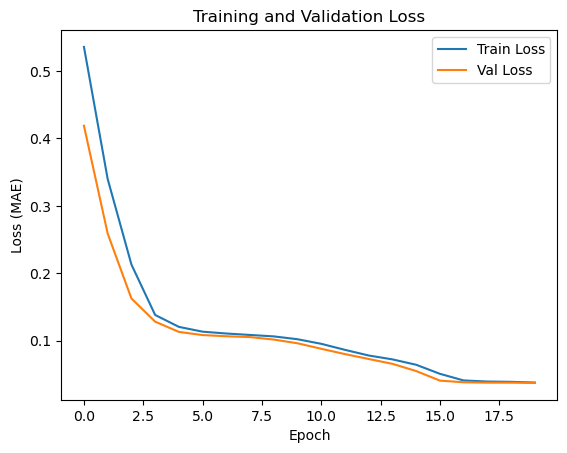

In [16]:
if __name__ == "__main__":
    train_autoencoder()